In [11]:
# pip install torch pyro-ppl sbi matplotlib

import torch
import pyro
import pyro.distributions as dist
import matplotlib.pyplot as plt

from pyro.infer import MCMC, NUTS

from sbi.inference import NPE, SMCABC
from sbi.utils import BoxUniform, MultipleIndependent


# ============================================================
# 0. REPRODUCIBILITY
# ============================================================

torch.manual_seed(123)
pyro.set_rng_seed(123)
pyro.clear_param_store()


# ============================================================
# 1. SETTINGS
# ============================================================

J = 3       # number of groups
N = 8       # observations per group

NPE_NUM_SIMS = 20_000
ABC_NUM_SIMS = 20_000

POST_SAMPLES = 2_000

x = torch.linspace(-1.0, 1.0, N)


# ============================================================
# 2. TRUE PARAMETERS
# ============================================================
#
# Hierarchical model:
#
# z_j ~ Normal(0, 1)
#
# alpha_j = mu_alpha + sigma_alpha * z_j
#
# y_ij ~ Normal(alpha_j + beta*x_ij, sigma_y)
#
# Global/population parameters:
#
# mu_alpha
# beta
# sigma_alpha
# sigma_y
#
# Group-level latent parameters:
#
# z_1, ..., z_J
#
# Actual group-level intercept:
#
# alpha_j = mu_alpha + sigma_alpha*z_j
#
# ============================================================

global_true = torch.tensor([
    0.5,    # mu_alpha
    1.2,    # beta
    0.6,    # sigma_alpha
    0.4,    # sigma_y
])

z_true = torch.tensor([
    -0.8,
     0.2,
     1.1,
])

theta_true = torch.cat([
    global_true,
    z_true,
])

parameter_names = [
    "mu_alpha",
    "beta",
    "sigma_alpha",
    "sigma_y",
] + [
    f"z_{j + 1}"
    for j in range(J)
]

alpha_true = (
    global_true[0]
    + global_true[2] * z_true
)

print("True global parameters:")
print(global_true)

print("\nTrue z:")
print(z_true)

print("\nTrue group intercepts alpha:")
print(alpha_true)


# ============================================================
# 3. COMMON PRIOR
# ============================================================
#
# The exact same prior is used by:
#
# 1. Pyro / NUTS
# 2. NPE
# 3. ABC-SMC
#
# ============================================================

global_prior = BoxUniform(
    low=torch.tensor([
        -3.0,   # mu_alpha
        -3.0,   # beta
         0.05,  # sigma_alpha
         0.05,  # sigma_y
    ]),
    high=torch.tensor([
        3.0,
        3.0,
        2.0,
        2.0,
    ]),
)

z_prior = torch.distributions.MultivariateNormal(
    loc=torch.zeros(J),
    covariance_matrix=torch.eye(J),
)

prior = MultipleIndependent([
    global_prior,
    z_prior,
])

True global parameters:
tensor([0.5000, 1.2000, 0.6000, 0.4000])

True z:
tensor([-0.8000,  0.2000,  1.1000])

True group intercepts alpha:
tensor([0.0200, 0.6200, 1.1600])


In [12]:
# ============================================================
# 4. SIMULATOR
# ============================================================
#
# theta contains ALL unknown parameters:
#
# theta =
#
# [mu_alpha,
#  beta,
#  sigma_alpha,
#  sigma_y,
#  z_1,
#  ...,
#  z_J]
#
# Therefore z is NOT randomly generated inside the simulator.
#
# The only simulator randomness is observation noise.
#
# ============================================================

def simulator(theta):

    theta = torch.as_tensor(
        theta,
        dtype=torch.float32,
    )

    single_sample = theta.ndim == 1

    if single_sample:
        theta = theta.unsqueeze(0)

    batch_size = theta.shape[0]

    # --------------------------------------------------------
    # Global parameters
    # --------------------------------------------------------

    mu_alpha = theta[:, 0]
    beta = theta[:, 1]
    sigma_alpha = theta[:, 2]
    sigma_y = theta[:, 3]

    # --------------------------------------------------------
    # Latent group effects
    # --------------------------------------------------------

    z = theta[:, 4:4 + J]

    # --------------------------------------------------------
    # Actual group intercepts
    #
    # alpha_j = mu + sigma_alpha * z_j
    # --------------------------------------------------------

    alpha = (
        mu_alpha[:, None]
        + sigma_alpha[:, None] * z
    )

    # --------------------------------------------------------
    # Linear predictor
    #
    # Shape:
    #
    # [batch, group, observation]
    # --------------------------------------------------------

    mean = (
        alpha[:, :, None]
        + beta[:, None, None]
        * x[None, None, :]
    )

    # --------------------------------------------------------
    # Generate observations
    # --------------------------------------------------------

    y = (
        mean
        + sigma_y[:, None, None]
        * torch.randn(
            batch_size,
            J,
            N,
        )
    )

    # --------------------------------------------------------
    # Flatten complete dataset
    #
    # SBI / ABC see ALL observations.
    #
    # shape:
    #
    # [batch, J*N]
    # --------------------------------------------------------

    y = y.reshape(
        batch_size,
        J * N,
    )

    if single_sample:
        return y.squeeze(0)

    return y


# ============================================================
# 5. GENERATE OBSERVED DATA
# ============================================================

y_obs = simulator(theta_true)

print("\nDimensions:")
print("theta_true:", theta_true.shape)
print("y_obs:     ", y_obs.shape)

# Here:
#
# theta dimension = 4 + J = 7
# data dimension  = J*N   = 24


Dimensions:
theta_true: torch.Size([7])
y_obs:      torch.Size([24])


In [13]:
# ============================================================
# 6. PYRO MODEL
# ============================================================
#
# This is the SAME hierarchical model, but Pyro has access
# to the likelihood.
#
# ============================================================

def pyro_model(y_flat):

    y = y_flat.reshape(J, N)

    # --------------------------------------------------------
    # Population-level priors
    # --------------------------------------------------------

    mu_alpha = pyro.sample(
        "mu_alpha",
        dist.Uniform(-3.0, 3.0),
    )

    beta = pyro.sample(
        "beta",
        dist.Uniform(-3.0, 3.0),
    )

    sigma_alpha = pyro.sample(
        "sigma_alpha",
        dist.Uniform(0.05, 2.0),
    )

    sigma_y = pyro.sample(
        "sigma_y",
        dist.Uniform(0.05, 2.0),
    )

    # --------------------------------------------------------
    # Non-centred group-level effects
    # --------------------------------------------------------

    z = pyro.sample(
        "z",
        dist.Normal(
            torch.zeros(J),
            torch.ones(J),
        ).to_event(1),
    )

    # --------------------------------------------------------
    # Group-specific intercepts
    # --------------------------------------------------------

    alpha = (
        mu_alpha
        + sigma_alpha * z
    )

    # --------------------------------------------------------
    # Expected response
    # --------------------------------------------------------

    mean = (
        alpha[:, None]
        + beta * x[None, :]
    )

    # --------------------------------------------------------
    # Likelihood
    # --------------------------------------------------------

    pyro.sample(
        "y",
        dist.Normal(
            mean,
            sigma_y,
        ).to_event(2),
        obs=y,
    )


# ============================================================
# 7. PYRO NUTS
# ============================================================

print("\n")
print("=" * 70)
print("RUNNING PYRO NUTS")
print("=" * 70)

nuts_kernel = NUTS(
    pyro_model,
    target_accept_prob=0.90,
)

mcmc = MCMC(
    nuts_kernel,
    warmup_steps=1_000,
    num_samples=POST_SAMPLES,
    num_chains=1,
)

mcmc.run(y_obs)

pyro_samples_raw = mcmc.get_samples()


# Combine global parameters + z into same format used by SBI

nuts_samples = torch.cat(
    [
        pyro_samples_raw["mu_alpha"][:, None],
        pyro_samples_raw["beta"][:, None],
        pyro_samples_raw["sigma_alpha"][:, None],
        pyro_samples_raw["sigma_y"][:, None],
        pyro_samples_raw["z"],
    ],
    dim=1,
)

print(
    "\nNUTS samples:",
    nuts_samples.shape,
)



RUNNING PYRO NUTS


Warmup:   0%|                                                                                                                                   | 0/3000 [00:00, ?it/s]/mnt/c/Users/james/projects/full-bayes-abc-sbi-comparison/.venv/lib/python3.11/site-packages/torch/autograd/graph.py:1072: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Sample: 100%|████████████████████████████████████████| 3000/3000 [04:45, 10.50it/s, step size=8.52e-02, acc. prob=0.921]                                            


NUTS samples: torch.Size([2000, 7])


In [14]:
# ============================================================
# 8. NPE
# ============================================================

print("\n")
print("=" * 70)
print("RUNNING NPE")
print("=" * 70)

# ------------------------------------------------------------
# Sample full parameter vectors from prior
# ------------------------------------------------------------

theta_npe = prior.sample(
    (NPE_NUM_SIMS,)
)

# ------------------------------------------------------------
# Generate corresponding datasets
# ------------------------------------------------------------

y_npe = simulator(
    theta_npe
)

print(
    "NPE theta shape:",
    theta_npe.shape,
)

print(
    "NPE y shape:",
    y_npe.shape,
)

# ------------------------------------------------------------
# Train NPE
# ------------------------------------------------------------

inference = NPE(
    prior=prior,
)

density_estimator = (
    inference
    .append_simulations(
        theta_npe,
        y_npe,
    )
    .train()
)

posterior = (
    inference
    .build_posterior(
        density_estimator
    )
)

posterior.set_default_x(
    y_obs
)

# ------------------------------------------------------------
# Draw posterior samples
# ------------------------------------------------------------

npe_samples = posterior.sample(
    (POST_SAMPLES,)
)

print(
    "NPE posterior samples:",
    npe_samples.shape,
)



RUNNING NPE
NPE theta shape: torch.Size([20000, 7])
NPE y shape: torch.Size([20000, 24])
 Neural network successfully converged after 222 epochs.

  0%|          | 0/2000 [00:00<?, ?it/s]

NPE posterior samples: torch.Size([2000, 7])


In [15]:
# ============================================================
# 9. ABC-SMC
# ============================================================

print("\n")
print("=" * 70)
print("RUNNING ABC-SMC")
print("=" * 70)

abc = SMCABC(
    simulator=simulator,
    prior=prior,

    # Compare complete simulated dataset against observed data
    distance="mse",

    # Beaumont et al. SMC-ABC variant
    algorithm_variant="C",

    # simulator supports batches
    simulation_batch_size=256,

    show_progress_bars=True,
)


abc_particles, abc_info = abc(

    # --------------------------------------------------------
    # IMPORTANT
    #
    # [24] -> [1, 24]
    #
    # One complete observed dataset containing 24 features.
    # --------------------------------------------------------

    x_o=y_obs.unsqueeze(0),

    # --------------------------------------------------------
    # SMC settings
    # --------------------------------------------------------

    num_particles=500,

    num_initial_pop=5_000,

    num_simulations=ABC_NUM_SIMS,

    epsilon_decay=0.8,

    distance_based_decay=True,

    return_summary=True,
)


print(
    "\nFinal ABC particle shape:",
    abc_particles.shape,
)


# ============================================================
# 10. ABC-SMC WEIGHTED RESAMPLING
# ============================================================
#
# abc_info["weights"] contains LOG weights.
#
# Convert to standard weights and resample so that we obtain
# an ordinary posterior sample comparable with NUTS / NPE.
#
# ============================================================

abc_log_weights = (
    abc_info["weights"][-1]
)

abc_weights = (
    abc_log_weights.exp()
)

abc_weights = (
    abc_weights
    / abc_weights.sum()
)

abc_samples = (
    SMCABC
    .sample_from_population_with_weights(
        particles=abc_particles,
        weights=abc_weights,
        num_samples=POST_SAMPLES,
    )
)

print(
    "ABC posterior samples:",
    abc_samples.shape,
)


# ============================================================
# 11. ABC EPSILON SEQUENCE
# ============================================================

print("\nABC epsilon sequence:")

for i, epsilon in enumerate(
    abc_info["epsilons"]
):

    print(
        f"Population {i:2d}: "
        f"epsilon = {float(epsilon):.5f}"
    )



RUNNING ABC-SMC


Running 5000 simulations.:   0%|          | 0/5000 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Running 321 simulations.:   0%|          | 0/321 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

...

Running 283 simulations.:   0%|          | 0/283 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Running 383 simulations.:   0%|          | 0/383 [00:00<?, ?it/s]

Running 280 simulations.:   0%|          | 0/280 [00:00<?, ?it/s]


Final ABC particle shape: torch.Size([500, 7])
ABC posterior samples: torch.Size([2000, 7])

ABC epsilon sequence:
Population  0: epsilon = 2.36591
Population  1: epsilon = 2.19277
Population  2: epsilon = 2.01804
Population  3: epsilon = 1.84023
Population  4: epsilon = 1.65888
Population  5: epsilon = 1.51254
Population  6: epsilon = 1.38734
Population  7: epsilon = 1.27392
Population  8: epsilon = 1.15901
Population  9: epsilon = 1.07376




PARAMETER POSTERIORS

mu_alpha (true = 0.500)
NUTS     mean=  0.489  median=  0.476  95% CI=( -0.591,   1.642)
NPE      mean=  0.494  median=  0.493  95% CI=( -0.573,   1.493)
ABC-SMC  mean=  0.437  median=  0.439  95% CI=( -0.928,   1.577)

beta (true = 1.200)
NUTS     mean=  1.087  median=  1.086  95% CI=(  0.880,   1.289)
NPE      mean=  1.100  median=  1.100  95% CI=(  0.871,   1.340)
ABC-SMC  mean=  1.058  median=  1.069  95% CI=( -0.105,   2.250)

sigma_alpha (true = 0.600)
NUTS     mean=  0.846  median=  0.757  95% CI=(  0.249,   1.845)
NPE      mean=  0.773  median=  0.757  95% CI=(  0.125,   1.565)
ABC-SMC  mean=  0.712  median=  0.629  95% CI=(  0.068,   1.743)

sigma_y (true = 0.400)
NUTS     mean=  0.323  median=  0.314  95% CI=(  0.235,   0.463)
NPE      mean=  0.327  median=  0.326  95% CI=(  0.106,   0.569)
ABC-SMC  mean=  0.395  median=  0.362  95% CI=(  0.058,   0.950)

z_1 (true = -0.800)
NUTS     mean= -0.689  median= -0.678  95% CI=( -2.145,   0.533)
NPE      mean

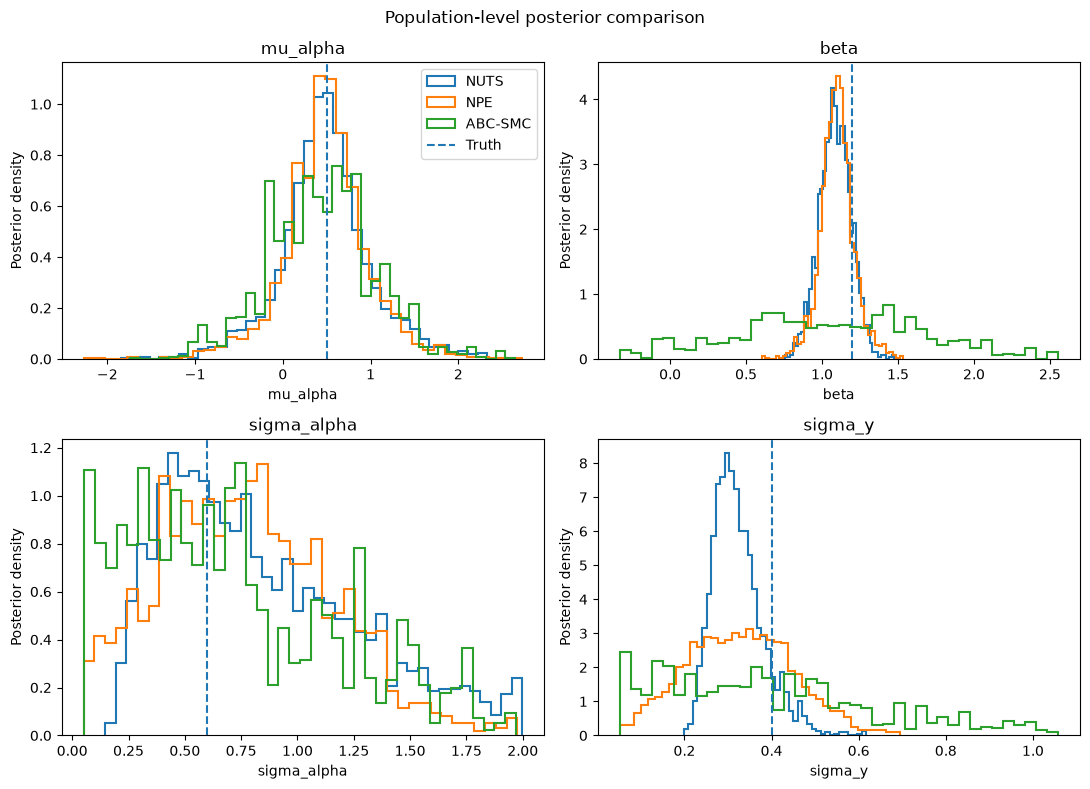

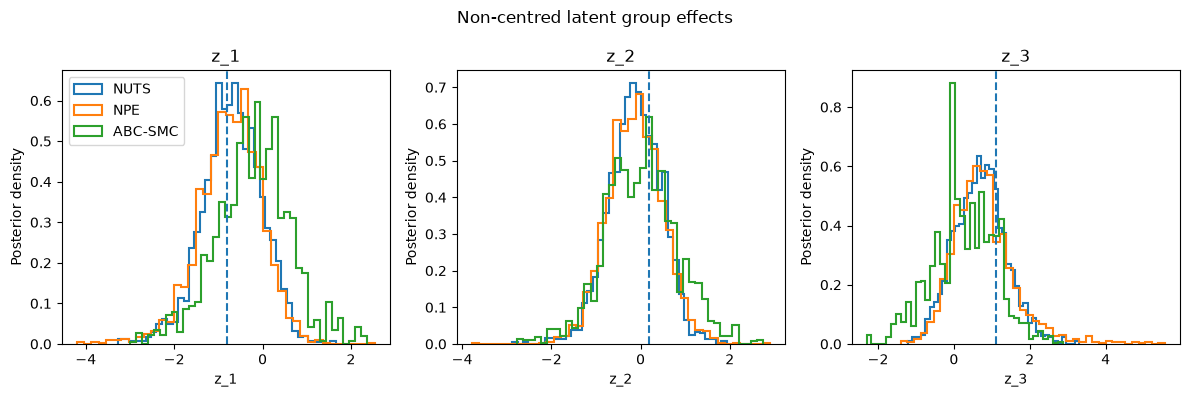

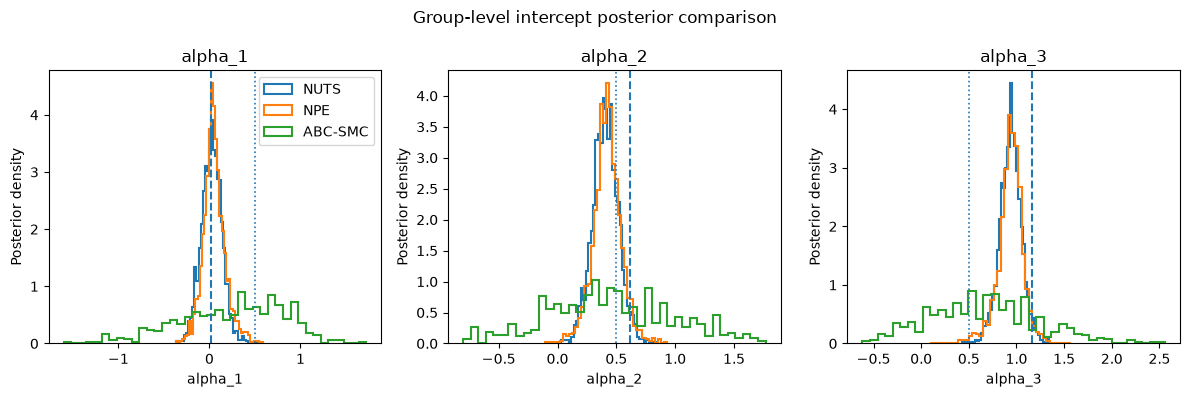



POSTERIOR MEAN DIFFERENCE FROM NUTS

NPE - NUTS:
mu_alpha    :  0.0056
beta        :  0.0128
sigma_alpha : -0.0731
sigma_y     :  0.0035
z_1         : -0.0466
z_2         : -0.0041
z_3         :  0.0844

ABC-SMC - NUTS:
mu_alpha    : -0.0514
beta        : -0.0285
sigma_alpha : -0.1340
sigma_y     :  0.0720
z_1         :  0.4674
z_2         :  0.1210
z_3         : -0.4226


GROUP INTERCEPT MEAN DIFFERENCE FROM NUTS

NPE - NUTS:
alpha_1:  0.0267
alpha_2:  0.0142
alpha_3: -0.0010

ABC-SMC - NUTS:
alpha_1:  0.2183
alpha_2:  0.0431
alpha_3: -0.2827


In [16]:
# ============================================================
# 12. DERIVE GROUP-LEVEL INTERCEPTS
# ============================================================
#
# We compare BOTH:
#
# z_j
#
# and the more interpretable:
#
# alpha_j = mu_alpha + sigma_alpha*z_j
#
# ============================================================

def get_alpha(samples):

    mu_alpha = samples[:, 0:1]

    sigma_alpha = samples[:, 2:3]

    z = samples[:, 4:4 + J]

    alpha = (
        mu_alpha
        + sigma_alpha * z
    )

    return alpha


alpha_nuts = get_alpha(
    nuts_samples
)

alpha_npe = get_alpha(
    npe_samples
)

alpha_abc = get_alpha(
    abc_samples
)


# ============================================================
# 13. POSTERIOR SUMMARY FUNCTION
# ============================================================

def posterior_summary(samples):

    mean = samples.mean(
        dim=0
    )

    median = torch.quantile(
        samples,
        0.50,
        dim=0,
    )

    lower = torch.quantile(
        samples,
        0.025,
        dim=0,
    )

    upper = torch.quantile(
        samples,
        0.975,
        dim=0,
    )

    return (
        mean,
        median,
        lower,
        upper,
    )


# ============================================================
# 14. GLOBAL + LATENT PARAMETER COMPARISON
# ============================================================

methods = {
    "NUTS": nuts_samples,
    "NPE": npe_samples,
    "ABC-SMC": abc_samples,
}


print("\n")
print("=" * 90)
print("PARAMETER POSTERIORS")
print("=" * 90)


for j, parameter in enumerate(
    parameter_names
):

    print(
        f"\n{parameter} "
        f"(true = {theta_true[j]:.3f})"
    )

    for method, samples in methods.items():

        (
            mean,
            median,
            lower,
            upper,
        ) = posterior_summary(
            samples
        )

        print(
            f"{method:8s} "
            f"mean={mean[j]:7.3f}  "
            f"median={median[j]:7.3f}  "
            f"95% CI="
            f"({lower[j]:7.3f}, "
            f"{upper[j]:7.3f})"
        )


# ============================================================
# 15. GROUP-LEVEL ALPHA COMPARISON
# ============================================================

alpha_methods = {
    "NUTS": alpha_nuts,
    "NPE": alpha_npe,
    "ABC-SMC": alpha_abc,
}


print("\n")
print("=" * 90)
print("GROUP-LEVEL INTERCEPT POSTERIORS")
print("=" * 90)


for j in range(J):

    print(
        f"\nalpha_{j + 1} "
        f"(true = {alpha_true[j]:.3f})"
    )

    for method, samples in alpha_methods.items():

        (
            mean,
            median,
            lower,
            upper,
        ) = posterior_summary(
            samples
        )

        print(
            f"{method:8s} "
            f"mean={mean[j]:7.3f}  "
            f"median={median[j]:7.3f}  "
            f"95% CI="
            f"({lower[j]:7.3f}, "
            f"{upper[j]:7.3f})"
        )


# ============================================================
# 16. POPULATION-LEVEL POSTERIOR PLOTS
# ============================================================

global_names = [
    "mu_alpha",
    "beta",
    "sigma_alpha",
    "sigma_y",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
)

axes = axes.flatten()

for j, ax in enumerate(axes):

    for method, samples in methods.items():

        ax.hist(
            samples[:, j]
            .detach()
            .cpu()
            .numpy(),

            bins=40,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=method,
        )

    ax.axvline(
        global_true[j].item(),
        linestyle="--",
        linewidth=1.5,
        label="Truth",
    )

    ax.set_title(
        global_names[j]
    )

    ax.set_xlabel(
        global_names[j]
    )

    ax.set_ylabel(
        "Posterior density"
    )


axes[0].legend()

fig.suptitle(
    "Population-level posterior comparison"
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. LATENT z POSTERIOR PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    J,
    figsize=(4 * J, 4),
)

if J == 1:
    axes = [axes]

for j in range(J):

    parameter_idx = 4 + j

    ax = axes[j]

    for method, samples in methods.items():

        ax.hist(
            samples[:, parameter_idx]
            .detach()
            .cpu()
            .numpy(),

            bins=40,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=method,
        )

    ax.axvline(
        z_true[j].item(),
        linestyle="--",
        linewidth=1.5,
    )

    ax.set_title(
        f"z_{j + 1}"
    )

    ax.set_xlabel(
        f"z_{j + 1}"
    )

    ax.set_ylabel(
        "Posterior density"
    )


axes[0].legend()

fig.suptitle(
    "Non-centred latent group effects"
)

plt.tight_layout()
plt.show()


# ============================================================
# 18. GROUP INTERCEPT POSTERIOR PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    J,
    figsize=(4 * J, 4),
)

if J == 1:
    axes = [axes]

for j in range(J):

    ax = axes[j]

    for method, samples in alpha_methods.items():

        ax.hist(
            samples[:, j]
            .detach()
            .cpu()
            .numpy(),

            bins=40,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=method,
        )

    ax.axvline(
        alpha_true[j].item(),
        linestyle="--",
        linewidth=1.5,
    )

    # Population mean shown for shrinkage reference
    ax.axvline(
        global_true[0].item(),
        linestyle=":",
        linewidth=1.2,
    )

    ax.set_title(
        f"alpha_{j + 1}"
    )

    ax.set_xlabel(
        f"alpha_{j + 1}"
    )

    ax.set_ylabel(
        "Posterior density"
    )


axes[0].legend()

fig.suptitle(
    "Group-level intercept posterior comparison"
)

plt.tight_layout()
plt.show()


# ============================================================
# 19. SIMPLE NUMERICAL COMPARISON AGAINST NUTS
# ============================================================

print("\n")
print("=" * 90)
print("POSTERIOR MEAN DIFFERENCE FROM NUTS")
print("=" * 90)

nuts_mean = nuts_samples.mean(0)

for method in ["NPE", "ABC-SMC"]:

    method_mean = methods[
        method
    ].mean(0)

    difference = (
        method_mean
        - nuts_mean
    )

    print(
        f"\n{method} - NUTS:"
    )

    for name, value in zip(
        parameter_names,
        difference,
    ):

        print(
            f"{name:12s}: "
            f"{value.item(): .4f}"
        )


# ============================================================
# 20. GROUP-LEVEL MEAN DIFFERENCE FROM NUTS
# ============================================================

print("\n")
print("=" * 90)
print("GROUP INTERCEPT MEAN DIFFERENCE FROM NUTS")
print("=" * 90)

alpha_nuts_mean = (
    alpha_nuts.mean(0)
)

for method in [
    "NPE",
    "ABC-SMC",
]:

    difference = (
        alpha_methods[method].mean(0)
        - alpha_nuts_mean
    )

    print(
        f"\n{method} - NUTS:"
    )

    for j, value in enumerate(
        difference
    ):

        print(
            f"alpha_{j + 1}: "
            f"{value.item(): .4f}"
        )